# Customer Churn Prediction Model

**Level 1 — Manual AI SDLC Demo**

This notebook demonstrates a typical Level 1 workflow:
- Data loaded from a local CSV (no schema validation)
- Preprocessing done inline with hardcoded paths
- Training and evaluation in a single notebook
- Manual model export as .pkl
- No version control on data or model
- No tests
- No reproducibility guarantees

In [1]:
# === CELL 1: Data Loading ===
# Hardcoded path — will break if file moves
import pandas as pd
import numpy as np
import os

DATA_PATH = "../data/customer_data.csv"
df = pd.read_csv(DATA_PATH)
print(f"Loaded {len(df)} rows from {DATA_PATH}")
df.head()

Loaded 50 rows from ../data/customer_data.csv


,customer_id,age,tenure_months,monthly_charges,total_charges,contract_type,payment_method,internet_service,tech_support,avg_monthly_usage_hours,late_payments_last_12m,churned
0,1001,34,12,75.5,906.0,Month-to-month,Electronic check,Fiber optic,No,45,3,1
1,1002,56,48,95.0,4560.0,Two year,Credit card,DSL,Yes,28,0,0
2,1003,28,6,45.0,270.0,Month-to-month,Mailed check,DSL,No,55,5,1
3,1004,45,36,110.0,3960.0,One year,Bank transfer,Fiber optic,Yes,35,1,0
4,1005,62,60,85.5,5130.0,Two year,Credit card,DSL,Yes,20,0,0


In [2]:
# === CELL 2: Quick EDA ===
# Manual inspection — no automated checks
print("=== MISSING VALUES ===")
print(df.isnull().sum())

print("\n=== TARGET DISTRIBUTION ===")
print(df['churned'].value_counts())
print(f"Churn rate: {df['churned'].mean():.2%}")

=== MISSING VALUES ===
customer_id                0
age                        0
tenure_months              0
monthly_charges            0
total_charges              0
contract_type              0
payment_method             0
internet_service           0
tech_support               0
avg_monthly_usage_hours    0
late_payments_last_12m     0
churned                    0
dtype: int64

=== TARGET DISTRIBUTION ===
churned
0    30
1    20
Name: count, dtype: int64
Churn rate: 40.00%


In [4]:
# === CELL 3: Manual Preprocessing ===
# No reusable pipeline — if we change the model, we rewrite this

df_clean = df.drop(columns=['customer_id'])

# Manual encoding — fragile, will break on unseen categories
df_clean['contract_type'] = df_clean['contract_type'].map({
    'Month-to-month': 0,
    'One year': 1,
    'Two year': 2
})

df_clean['payment_method'] = df_clean['payment_method'].map({
    'Electronic check': 0,
    'Mailed check': 1,
    'Bank transfer': 2,
    'Credit card': 3
})

df_clean['internet_service'] = df_clean['internet_service'].map({
    'DSL': 0,
    'Fiber optic': 1
})

df_clean['tech_support'] = df_clean['tech_support'].map({'No': 0, 'Yes': 1})

# Manual train/test split — random seed changes each run
np.random.seed(42)
train_idx = np.random.rand(len(df_clean)) < 0.8
train = df_clean[train_idx]
test = df_clean[~train_idx]

X_train = train.drop(columns=['churned'])
y_train = train['churned']
X_test = test.drop(columns=['churned'])
y_test = test['churned']

print(f"Train: {len(X_train)} rows, Test: {len(X_test)} rows")

Train: 42 rows, Test: 8 rows


In [5]:
# === CELL 4: Model Training (Random Forest) ===
# Hyperparameters chosen by guessing — no sweep, no tracking
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("=== MODEL PERFORMANCE ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred):.3f}")
print(f"F1 Score:  {f1_score(y_test, y_pred):.3f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

=== MODEL PERFORMANCE ===
Accuracy:  1.000
Precision: 1.000
Recall:    1.000
F1 Score:  1.000

Confusion Matrix:
[[6 0]
 [0 2]]


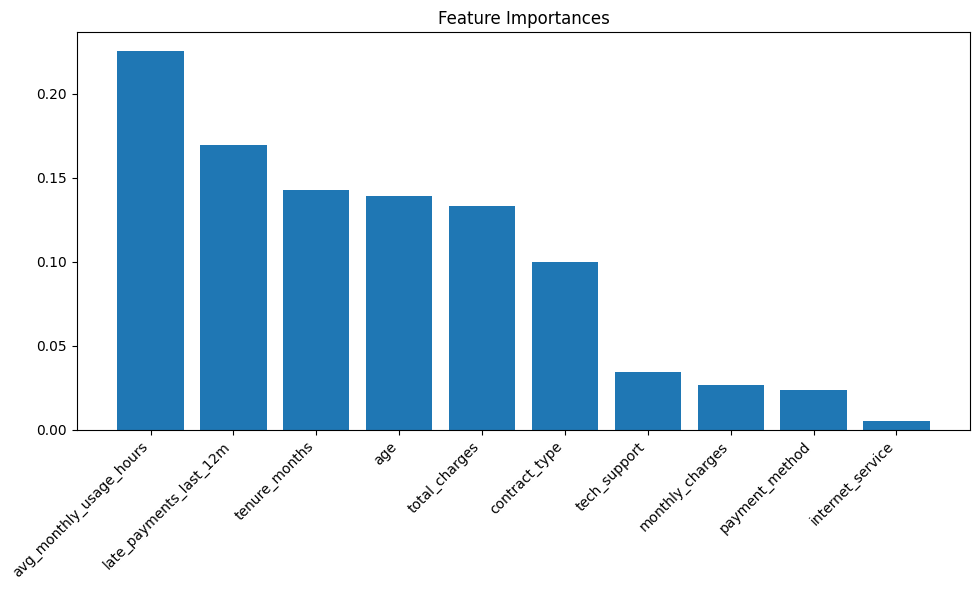

In [6]:
# === CELL 5: Feature Importance ===
# Quick check — results not saved anywhere
import matplotlib.pyplot as plt

importances = model.feature_importances_
features = X_train.columns
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Feature Importances")
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), [features[i] for i in indices], rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [7]:
# === CELL 6: Manual Model Export ===
# Exported as .pkl — no version, no metadata, no registry
# If someone deletes this file, models cannot be reproduced
import joblib
import datetime

MODEL_PATH = f"../models/churn_model_{datetime.date.today().isoformat()}.pkl"
joblib.dump(model, MODEL_PATH)
print(f"Model saved to {MODEL_PATH}")
print(f"Model size: {os.path.getsize(MODEL_PATH) / 1024:.1f} KB")

Model saved to ../models/churn_model_2026-06-21.pkl
Model size: 101.2 KB


In [8]:
# === CELL 7: Quick Demo — Predict a Single Customer ===
# Used to copy-paste results into an email to stakeholders
sample = X_test.iloc[:3]
predictions = model.predict(sample)
probabilities = model.predict_proba(sample)

for i, (pred, prob) in enumerate(zip(predictions, probabilities)):
    print(f"Customer {i+1}: {'CHURN' if pred else 'STAY'} (confidence: {max(prob):.1%})")

Customer 1: STAY (confidence: 100.0%)
Customer 2: STAY (confidence: 96.0%)
Customer 3: STAY (confidence: 100.0%)


---

## Level 1 Anti-Patterns Demonstrated

| Anti-Pattern | Where | Why It's a Problem |
|---|---|---|
| Hardcoded data path | Cell 1 | Breaks if file moves or runs on another machine |
| No data validation | Cell 2 | Schema drift goes undetected |
| Manual encoding | Cell 3 | Unseen categories crash the pipeline |
| Random seed not enforced | Cell 3 | Different split each run → irreproducible |
| Guessed hyperparameters | Cell 4 | No record of why these values were chosen |
| No experiment tracking | N/A | Can't tell which run produced this model |
| Model saved as bare .pkl | Cell 6 | No version, no lineage, easy to lose |
| No automated tests | N/A | Regressions reach production silently |
| Manual deployment needed | Cell 7 | Model is a file — getting it to prod is a separate headache |

## Next Step

See the business case in this folder for the investment case to move to **Level 2**.